# Drug Review Sentiment Analysis using TextBlob NLP

This project analyzes patient drug reviews using Natural Language Processing (NLP). TextBlob is used to calculate sentiment polarity and subjectivity scores, which are then compared with user ratings through exploratory data analysis and linear regression.

Objectives:
- Analyze review sentiment
- Explore sentiment-rating relationships
- Validate TextBlob polarity using statistical analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import  html, warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the dataset
df = pd.read_csv('/content/drugsComTest_raw.csv')
df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,163740,Mirtazapine,Depression,"""I&#039;ve tried a few antidepressants over th...",10,28-Feb-12,22
1,206473,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn&#039;s disease and has done ...",8,17-May-09,17
2,159672,Bactrim,Urinary Tract Infection,"""Quick reduction of symptoms""",9,29-Sep-17,3
3,39293,Contrave,Weight Loss,"""Contrave combines drugs that were used for al...",9,5-Mar-17,35
4,97768,Cyclafem 1 / 35,Birth Control,"""I have been on this birth control for one cyc...",9,22-Oct-15,4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53766 entries, 0 to 53765
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   uniqueID     53766 non-null  int64 
 1   drugName     53766 non-null  object
 2   condition    53471 non-null  object
 3   review       53766 non-null  object
 4   rating       53766 non-null  int64 
 5   date         53766 non-null  object
 6   usefulCount  53766 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 2.9+ MB


In [4]:
df.describe()

,uniqueID,rating,usefulCount
count,53766.000000,53766.000000,53766.000000
mean,116386.701187,6.976900,27.989752
std,67017.739881,3.285207,36.172833
min,0.000000,1.000000,0.000000
25%,58272.500000,4.000000,6.000000
50%,116248.500000,8.000000,16.000000
75%,174586.750000,10.000000,36.000000
max,232284.000000,10.000000,949.000000


In [5]:
df.shape

(53766, 7)

In [6]:
# Check missing values
df.isnull().sum()

,0
uniqueID,0
drugName,0
condition,295
review,0
rating,0
date,0
usefulCount,0


## Data Preprocessing

The raw dataset contains HTML entities, inconsistent formatting, and missing values. The following steps are performed to prepare the data for sentiment analysis:

- Remove missing records
- Decode HTML entities
- Convert text to lowercase
- Normalize whitespace

In [7]:
#checking duplicated values
df.duplicated().sum()

np.int64(0)

In [8]:
# Step 3: Drop nulls
df = df.dropna(subset=['condition'])

In [9]:
#checking after dropping null values
df['condition'].isnull().sum()

np.int64(0)

In [10]:
#Decoding HTML entities (e.g., &#039; -> ')
df['review_clean'] = df['review'].apply(lambda x: html.unescape(str(x)))
#converting everything to lowercase and removing extra spaces
df['review_clean'] = df['review_clean'].str.lower().str.strip()

## Sentiment Analysis using TextBlob

TextBlob assigns two important metrics to each review:

- Polarity (-1 to +1): Measures positive or negative sentiment
- Subjectivity (0 to 1): Measures how opinion-based the text is

Reviews are classified as Positive, Neutral, or Negative based on polarity thresholds.

In [11]:
# Sentiment analysis using TextBlob
# polarity > 0.1  -> Positive
# polarity < -0.1 -> Negative
# else            -> Neutral

# Get polarity
df['polarity'] = df['review_clean'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# Get subjectivity
df['subjectivity'] = df['review_clean'].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)

# Get sentiment label
def get_label(p):
    if p > 0.1:
        return 'Positive'
    elif p < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_label'] = df['polarity'].apply(get_label)

# Check results
print(df['sentiment_label'].value_counts())
df[['review', 'sentiment_label', 'polarity']].head()

sentiment_label
Neutral     23355
Positive    21183
Negative     8933
Name: count, dtype: int64


,review,sentiment_label,polarity
0,"""I&#039;ve tried a few antidepressants over th...",Neutral,0.000000
1,"""My son has Crohn&#039;s disease and has done ...",Positive,0.566667
2,"""Quick reduction of symptoms""",Positive,0.333333
3,"""Contrave combines drugs that were used for al...",Positive,0.139063
4,"""I have been on this birth control for one cyc...",Positive,0.260926


In [12]:
#grouping
print(df.groupby('sentiment_label')['rating'].mean())

sentiment_label
Negative    4.811150
Neutral     6.805866
Positive    8.078601
Name: rating, dtype: float64


## Correlation Analysis

To evaluate whether review sentiment aligns with user satisfaction, the Pearson correlation coefficient is calculated between polarity scores and numerical ratings.

A positive correlation would indicate that more positive reviews generally receive higher ratings.

In [13]:
corr = df['polarity'].corr(df['rating'])
print(f'Pearson Correlation (polarity vs rating): {corr}')

Pearson Correlation (polarity vs rating): 0.34633219826740475


## Sentiment Summary

The following statistics provide an overview of the sentiment distribution in the dataset after TextBlob classification.

In [14]:
#Summary
total = len(df)
pos = (df['sentiment_label'] == 'Positive').sum()
neu = (df['sentiment_label'] == 'Neutral').sum()
neg = (df['sentiment_label'] == 'Negative').sum()

print(f'Total Reviews: {total}')
print(f'Positive: {pos} ({pos/total*100:.1f}%)')
print(f'Neutral:  {neu} ({neu/total*100:.1f}%)')
print(f'Negative: {neg} ({neg/total*100:.1f}%)')
print(f'Avg Polarity: {df["polarity"].mean():.4f}')
print(f'Polarity-Rating Correlation: {df["polarity"].corr(df["rating"]):.4f}')

Total Reviews: 53471
Positive: 21183 (39.6%)
Neutral:  23355 (43.7%)
Negative: 8933 (16.7%)
Avg Polarity: 0.0640
Polarity-Rating Correlation: 0.3463


## Exploratory Data Analysis

The following visualizations help understand:

- Distribution of sentiments
- Distribution of ratings
- Polarity score patterns
- Relationship between sentiment and ratings
- Relationship between polarity and subjectivity

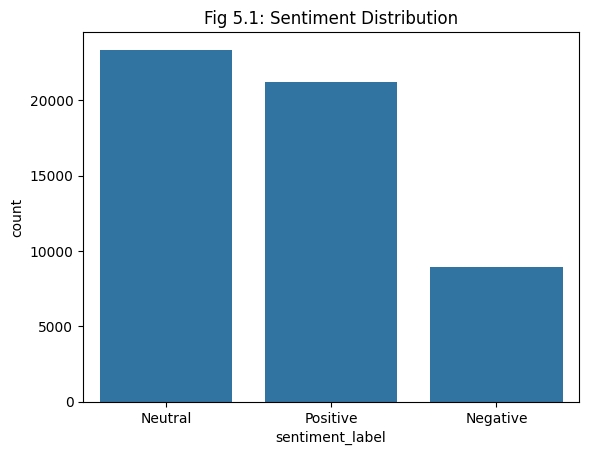

In [15]:
#Plot 1: Sentiment Distribution
sns.countplot(x='sentiment_label', data=df)
plt.title('Fig 5.1: Sentiment Distribution')
plt.show()

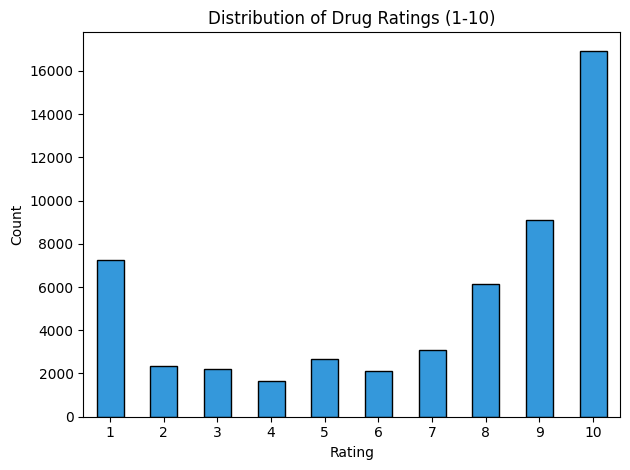

In [16]:
# Plot 2: Rating Distribution
df['rating'].value_counts().sort_index().plot(kind='bar', color='#3498db', edgecolor='black')
plt.title('Distribution of Drug Ratings (1-10)')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

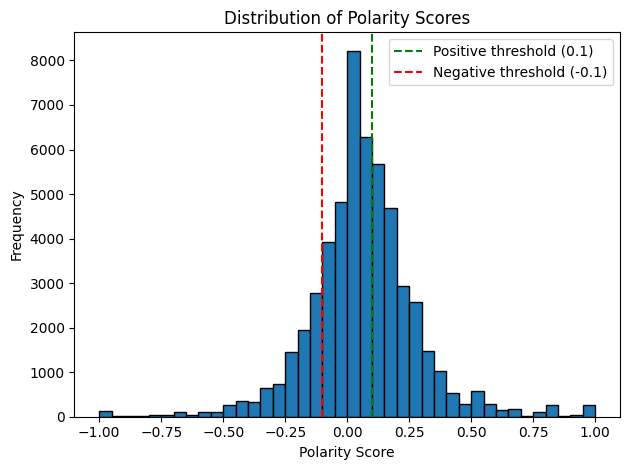

In [17]:
# Plot 3: Polarity Score Distribution
plt.hist(df['polarity'], bins=40,edgecolor='black')
plt.axvline(0.1,  color='green', linestyle='--', label='Positive threshold (0.1)')
plt.axvline(-0.1, color='red',   linestyle='--', label='Negative threshold (-0.1)')
plt.title('Distribution of Polarity Scores')
plt.xlabel('Polarity Score')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

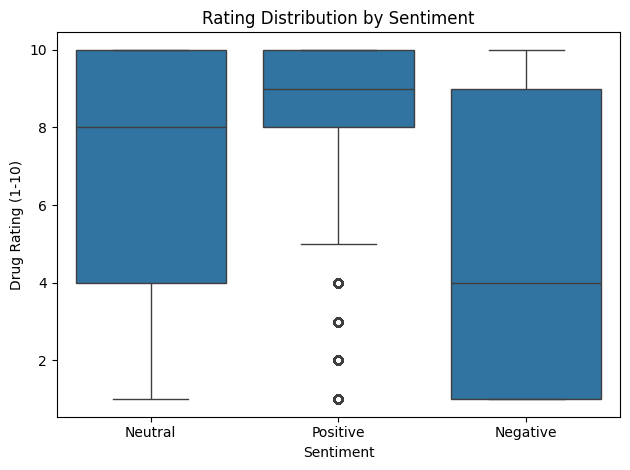

In [18]:
# Plot 4: Rating Distribution by Sentiment (Box Plot)
order = ['Negative', 'Neutral', 'Positive']
sns.boxplot(data=df, x='sentiment_label', y='rating')
plt.title('Rating Distribution by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Drug Rating (1-10)')
plt.tight_layout()
plt.show()

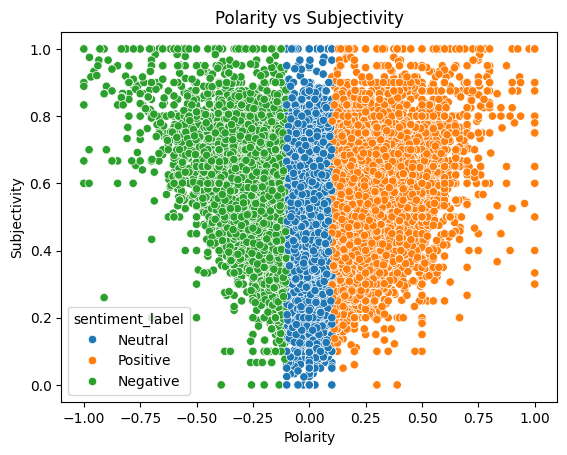

In [19]:
# Plot 5: Polarity vs Subjectivity Scatter
sns.scatterplot(x='polarity', y='subjectivity', hue='sentiment_label', data=df)
plt.title('Polarity vs Subjectivity')
plt.xlabel('Polarity')
plt.ylabel('Subjectivity')

plt.show()

## Linear Regression

A simple Linear Regression model is trained using polarity as the input feature and rating as the target variable.

The objective is not to build a highly accurate predictor but to investigate whether sentiment polarity has a measurable relationship with user ratings.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Input (feature)
X = df[['polarity']]

# Output (target)
y = df['rating']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_pred

array([7.05525029, 7.37847275, 7.53098666, ..., 7.31586178, 8.06469614,
       7.29017523])

In [21]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R² Score:", round(r2,3))
print("MAE:", round(mae,3))

R² Score: 0.115
MAE: 2.617


**R² Score Analysis**

The Linear Regression model achieved an R² score of 0.115. This indicates that approximately 11.5% of the variation in drug ratings can be explained by TextBlob polarity scores alone.

Although the predictive power of the model is limited, the positive relationship confirms that review sentiment has a measurable influence on user ratings. The relatively low R² value is expected because drug ratings are affected by several additional factors, including treatment effectiveness, side effects, patient expectations, and individual medical conditions, which are not captured by sentiment polarity alone.

Therefore, while polarity is a useful indicator of overall patient satisfaction, it is not sufficient by itself to accurately predict drug ratings.

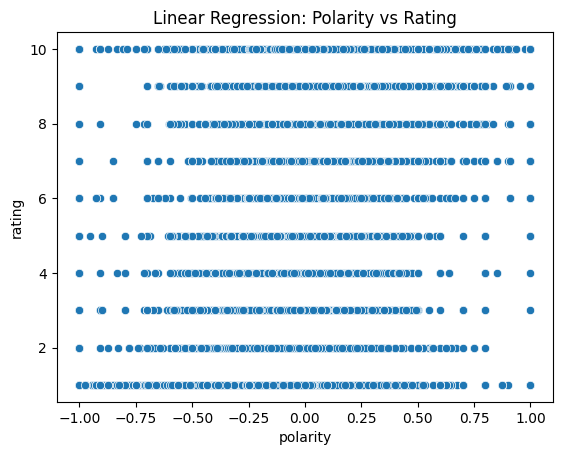

In [22]:
#Plot 6 : Polarity vs Rating Scatter Plot
sns.scatterplot(x='polarity', y='rating', data=df)
plt.title('Polarity vs Rating Scatter Plot')
plt.show()

## Conclusion

The analysis shows that TextBlob polarity scores are positively related to user ratings. While sentiment alone cannot fully predict drug ratings, it provides useful insights into patient satisfaction and demonstrates the effectiveness of basic NLP techniques on healthcare review data.